Predicción de gastos médicos
===

* *45 min*

En este tutorial se construye un modelo de regresión lineal para la predicción de gastos médicos por parte de una aseguradora.

Al finalizar este tutorial, usted estará en capacidad de:

* Realizar el análisis exploratorio de datos para aplicar técnicas de regresión.


* Estimar un modelo de regresión lineal usando el lenguaje R.


* Realiar el diagnóstico del modelo.


* Establecer posibles mejoras al modelo.

## Definición del problema

Una compañía de seguros desea pronósticar los gastos médicos de la población asegurada con el fin de recolectar un valor superior en ingresos, tal que le permita obtener utilidades. Los costos son difíciles de pronósticar ya que las condiciones más costosas son más raras y parecen aleatorias; y que ciertas condiciones son más probables para ciertos segmentos de la población (infarto en personas obesas y cáncer en fumadores).

El objetivo es usar una base de datos con 1338 registros de gastos médicos hipotéticos para pacientes de EU con el fin de estimar los costos para determinados segmentos de la población. La información registrada es la siguiente:

* Age: entero hasta 64.

* Sex: male, female.

* bmi: Body mass index.

* children: entero indicando la cantidad de hijos/dependientes cubiertos por el plan de salud.

* smoker: yes, no.

* region: northest, southeast, southwest, northwest.

* charges: costos.


## Solución

### Análisis Exploratorio

In [1]:
##
## Carga y verificación de los datos.
## La variable charges es la que se desea pronósticar.
##
insurance <- read.csv("data/insurance.csv", stringsAsFactors = TRUE)

##
## Se verifica que los datos hayan sido leidos correctamente.
## Se verifican los valores de las variables buscando cualquier
## problema de lectura.
##
str(insurance)

'data.frame':	1338 obs. of  7 variables:
 $ age     : int  19 18 28 33 32 31 46 37 37 60 ...
 $ sex     : Factor w/ 2 levels "female","male": 1 2 2 2 2 1 1 1 2 1 ...
 $ bmi     : num  27.9 33.8 33 22.7 28.9 ...
 $ children: int  0 1 3 0 0 0 1 3 2 0 ...
 $ smoker  : Factor w/ 2 levels "no","yes": 2 1 1 1 1 1 1 1 1 1 ...
 $ region  : Factor w/ 4 levels "northeast","northwest",..: 4 3 3 2 2 3 3 2 1 2 ...
 $ charges : num  16885 1726 4449 21984 3867 ...


In [2]:
##
## Información estadística de la variable dependiente.
## Se busca cualquier indicio de irregularidades, 
## especialmente datos atípicos, información faltante, etc.
##
summary(insurance$charges)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1122    4740    9382   13270   16640   63770 

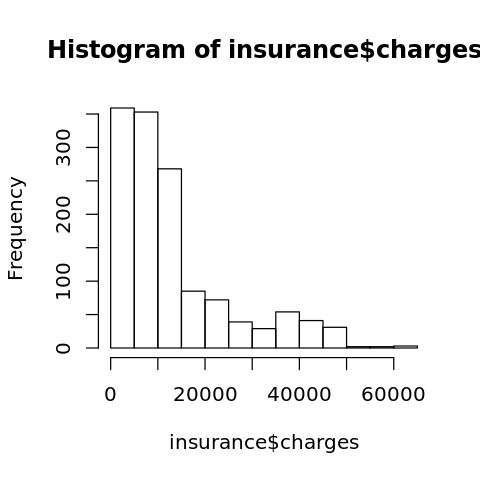

In [3]:
##
## histograma.
## Muestra que la mayor parte de la población tiene 
## gastos bajos, mientras que disminuye la frecuencia
## de costos más altos es más baja.
##
options(repr.plot.width = 4, repr.plot.height = 4)
hist(insurance$charges)

In [4]:
##
## Se evalua la cantidad de casos por región.
## Todas las regiones tienen aproximadamente
## la misma cantidad de casos.
##
table(insurance$region)


northeast northwest southeast southwest 
      324       325       364       325 

In [5]:
##
## El análisis de correlación muestra que 
## existe una mayor correlación de los gastos
## con la edad y el bmi, pero no con la 
## cantidad de dependientes.
##
cor(insurance[c("age", "bmi", "children", "charges")])

,age,bmi,children,charges
age,1.0000000,0.1092719,0.04246900,0.29900819
bmi,0.1092719,1.0000000,0.01275890,0.19834097
children,0.0424690,0.0127589,1.00000000,0.06799823
charges,0.2990082,0.1983410,0.06799823,1.00000000


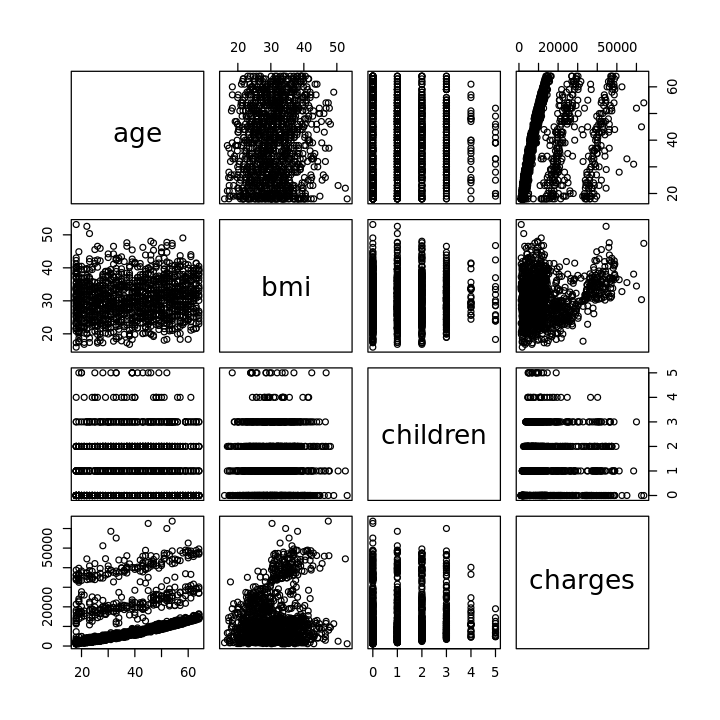

In [17]:
##
## Se construye la siguiente gráfica para
## visualizar relaciones entre las variables
##
options(repr.plot.width = 6, repr.plot.height = 6)
pairs(insurance[c("age", "bmi", "children", "charges")])

##
## la gráfica muestra una relación entre age y charges, 
## y dos grupos para bmi y charges.
##

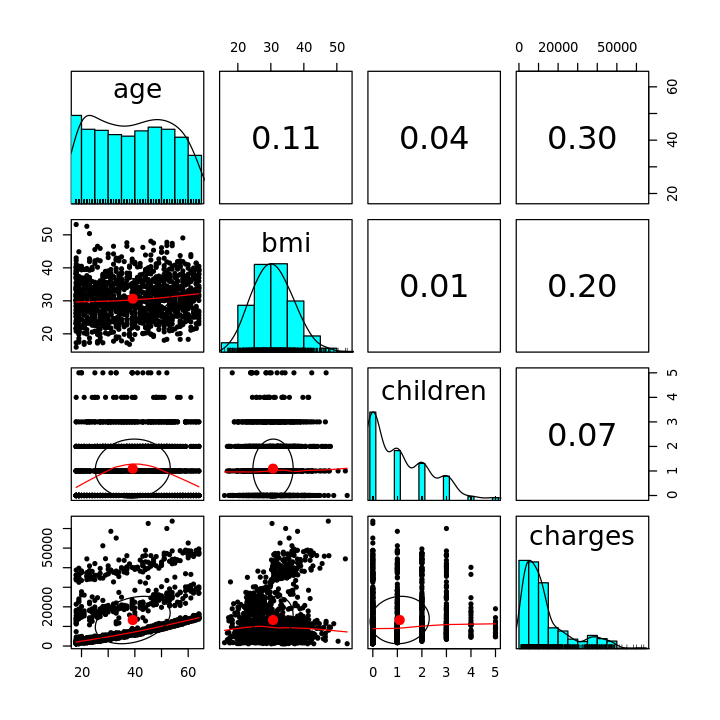

In [18]:
##
## Una gráfica más informativa se obtiene de con la 
## función pairs.panels().
##
# install.packages("psych")
##
library(psych)
options(repr.plot.width = 6, repr.plot.height = 6)
pairs.panels(insurance[c("age", "bmi", "children", "charges")])

### Entrenamiento del modelo

In [8]:
##
## Se usa la función lm para estimar el modelo de
## regresión lineal.
##
ins_model <- lm(charges ~ age + children + bmi + sex + smoker + region, 
                data = insurance)

##
## Se imprimen los parámetros del modelo
##
ins_model


Call:
lm(formula = charges ~ age + children + bmi + sex + smoker + 
    region, data = insurance)

Coefficients:
    (Intercept)              age         children              bmi  
       -11938.5            256.9            475.5            339.2  
        sexmale        smokeryes  regionnorthwest  regionsoutheast  
         -131.3          23848.5           -353.0          -1035.0  
regionsouthwest  
         -960.1  


In [9]:
##
## Ya que el modelo usa todas las variables 
## explicativas disponibles, la llamada a la
## función puede simplificarse como:
##
ins_model <- lm(charges ~ ., data = insurance)
ins_model


Call:
lm(formula = charges ~ ., data = insurance)

Coefficients:
    (Intercept)              age          sexmale              bmi  
       -11938.5            256.9           -131.3            339.2  
       children        smokeryes  regionnorthwest  regionsoutheast  
          475.5          23848.5           -353.0          -1035.0  
regionsouthwest  
         -960.1  


### Diagnóstico del modelo

#### Coeficientes del modelo

In [10]:
## 
## Se imprime un resumen del modelo estimado.
## El primer paso consiste en eliminar las variables 
## irrelevantes. En este caso, se eliminaría la variable
## `sexmale` (valor más alto de Pr(>|t|)) y se estimaría
## el modelo nuevamente. Se eliminaría la siguiente variable
## más irrelevante y así sucesivamente hasta que solo queden
## variables relevantes en el modelo
##
summary(ins_model)


Call:
lm(formula = charges ~ ., data = insurance)

Residuals:
     Min       1Q   Median       3Q      Max 
-11304.9  -2848.1   -982.1   1393.9  29992.8 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -11938.5      987.8 -12.086  < 2e-16 ***
age                256.9       11.9  21.587  < 2e-16 ***
sexmale           -131.3      332.9  -0.394 0.693348    
bmi                339.2       28.6  11.860  < 2e-16 ***
children           475.5      137.8   3.451 0.000577 ***
smokeryes        23848.5      413.1  57.723  < 2e-16 ***
regionnorthwest   -353.0      476.3  -0.741 0.458769    
regionsoutheast  -1035.0      478.7  -2.162 0.030782 *  
regionsouthwest   -960.0      477.9  -2.009 0.044765 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6062 on 1329 degrees of freedom
Multiple R-squared:  0.7509,	Adjusted R-squared:  0.7494 
F-statistic: 500.8 on 8 and 1329 DF,  p-value: < 2.2e-16


#### Análisis de residuales

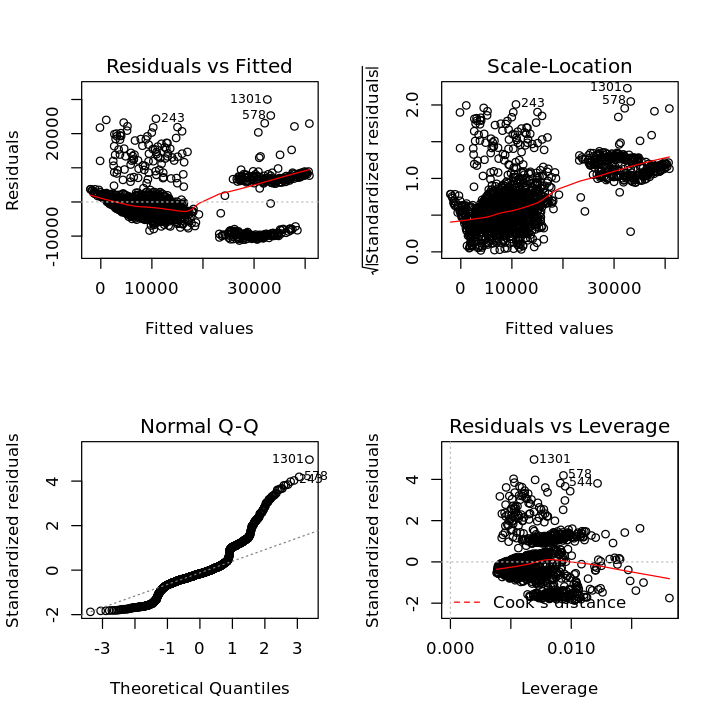

In [19]:
##
## Se construye una gráfica de 2x2
##
layout(matrix(c(1,2,3,4),2,2))
options(repr.plot.width = 6, repr.plot.height = 6)
##
## Se realizan los gráficos de 
## dignóstico del modelo.
##
plot(ins_model)

##
## El gráfico QQ muesta que el modelo
## no captura adecuadamente el comportamiento
## Los demás grafos corroboran esto.
##

### Mejora del modelo

En un modelo lineal es posible considerar relaciones no lineales por medio de la transformación de las variables. En el siguiente caso se agrega la edad al cuadrado al dataframe.

In [12]:
insurance$age2 <- insurance$age^2

Adicionalmente, se considera que la variable bmi podría ser reemplazada simplemente por una variable indicadora que toma el valor de 1 si el bmi es igual o mayor a 30, y cero en caso contrario. 

In [13]:
insurance$bmi30 <- ifelse(insurance$bmi >= 30, 1, 0)

Más aún, es posible considerar la interacción de dos o más variables. En el siguiente caso, se considera la interación de smoker y bmi30. La notación var1:var2 es equivalente a var1 + var2 + var1*var2. 

In [14]:
##
## El siguiente model considera simultáneamente 
## el efecto no lineal de la edad, si la persona es 
## obesa y la interacción entre obesidad y que la persona
## sea fumadora.
##
ins_model2 <- lm(charges ~ age + age2 + children + bmi + sex + bmi30*smoker + region, 
                 data = insurance)
summary(ins_model2)


Call:
lm(formula = charges ~ age + age2 + children + bmi + sex + bmi30 * 
    smoker + region, data = insurance)

Residuals:
     Min       1Q   Median       3Q      Max 
-17296.4  -1656.0  -1263.3   -722.1  24160.2 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       134.2509  1362.7511   0.099 0.921539    
age               -32.6851    59.8242  -0.546 0.584915    
age2                3.7316     0.7463   5.000 6.50e-07 ***
children          678.5612   105.8831   6.409 2.04e-10 ***
bmi               120.0196    34.2660   3.503 0.000476 ***
sexmale          -496.8245   244.3659  -2.033 0.042240 *  
bmi30           -1000.1403   422.8402  -2.365 0.018159 *  
smokeryes       13404.6866   439.9491  30.469  < 2e-16 ***
regionnorthwest  -279.2038   349.2746  -0.799 0.424212    
regionsoutheast  -828.5467   351.6352  -2.356 0.018604 *  
regionsouthwest -1222.6437   350.5285  -3.488 0.000503 ***
bmi30:smokeryes 19810.7533   604.6567  32.764  < 2e-16 ***


Nóte que este modelo tiene un r2 superior al del modelo original.

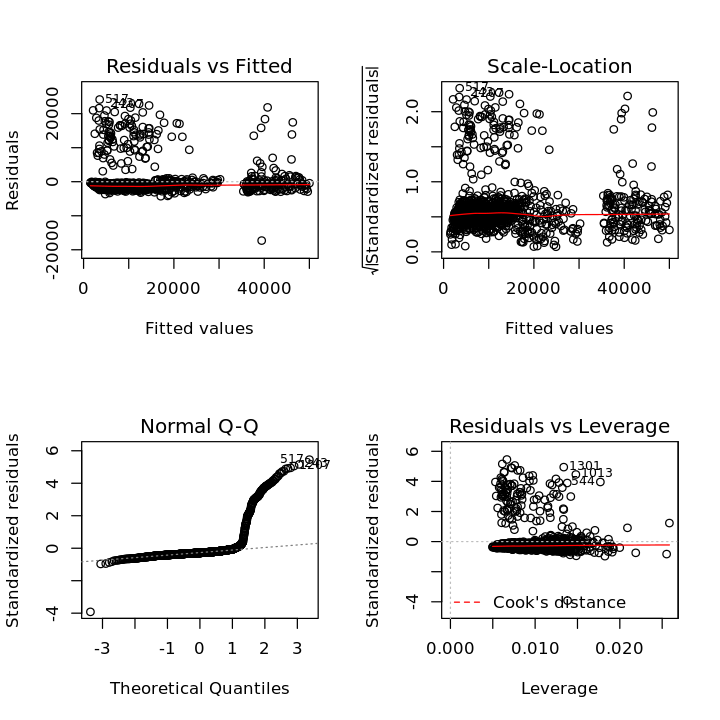

In [20]:
##
## Los gráficos de diagnóstico mejoran mucho
## pero aún el modelo podría mejorarse aún más
## usando otras técnicas.
##
options(repr.plot.width = 6, repr.plot.height = 6)
layout(matrix(c(1,2,3,4),2,2))
plot(ins_model2)

---